<a href="https://colab.research.google.com/github/HardikDk121/Brain-Tumor-Classification/blob/main/ResNetModel_Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 BRISC Binary Classification: Model Evaluation
This notebook evaluates multiple pre-trained ResNet-18 models on the BRISC 2025 classification dataset.

## 1. Setup and Environment
Mount Google Drive to access saved model weights and fetch the dataset from Kaggle.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import kagglehub

# Download latest version
brics_test_path = kagglehub.dataset_download("briscdataset/brisc2025")

print("Path to dataset files:", brics_test_path)

Using Colab cache for faster access to the 'brisc2025' dataset.
Path to dataset files: /kaggle/input/brisc2025


In [3]:
!find {brics_test_path} -maxdepth 3

/kaggle/input/brisc2025
/kaggle/input/brisc2025/brisc2025
/kaggle/input/brisc2025/brisc2025/manifest.json
/kaggle/input/brisc2025/brisc2025/README.md
/kaggle/input/brisc2025/brisc2025/segmentation_task
/kaggle/input/brisc2025/brisc2025/segmentation_task/test
/kaggle/input/brisc2025/brisc2025/segmentation_task/train
/kaggle/input/brisc2025/brisc2025/classification_task
/kaggle/input/brisc2025/brisc2025/classification_task/test
/kaggle/input/brisc2025/brisc2025/classification_task/train
/kaggle/input/brisc2025/brisc2025/manifest.csv
/kaggle/input/brisc2025/brisc2025/manifest.json.sha256
/kaggle/input/brisc2025/brisc2025/manifest.csv.sha256


In [4]:
import kagglehub

# Download latest version
fig_share_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", fig_share_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [5]:
!find {fig_share_path} -maxdepth 2

/kaggle/input/brain-tumor-mri-dataset
/kaggle/input/brain-tumor-mri-dataset/Training
/kaggle/input/brain-tumor-mri-dataset/Training/pituitary
/kaggle/input/brain-tumor-mri-dataset/Training/notumor
/kaggle/input/brain-tumor-mri-dataset/Training/meningioma
/kaggle/input/brain-tumor-mri-dataset/Training/glioma
/kaggle/input/brain-tumor-mri-dataset/Testing
/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary
/kaggle/input/brain-tumor-mri-dataset/Testing/notumor
/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma
/kaggle/input/brain-tumor-mri-dataset/Testing/glioma


In [6]:
BRICS_TEST_DIR = brics_test_path +'/brisc2025/classification_task/test/'
FIG_SHARE_TEST_DIR = fig_share_path + '/Testing/'
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 0.001
input_size = 224
reshape_size =256

## 2. Imports and Configuration
Load all necessary libraries and set the global hyperparameters and directory paths.

In [7]:
%pip install grad-cam shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.7 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=b45b48ab5d036c292e54c3b0bff0f30cfb993afed1224bf8fba726a492dc53e7
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [8]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
from PIL import Image
import os
import cv2
from torch.utils.data import DataLoader

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

## 3. Data Loading and Preprocessing
Define the image transformations and initialize the test DataLoader.

In [9]:
def opencv_crop_and_clahe_loader(image_path):
    # 1. Load the image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image not found. Check the path: {image_path}")

    # 2. Convert to grayscale for thresholding
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 3. Crop using contours
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cropped_gray = gray[y:y+h, x:x+w] 
    else:
        cropped_gray = gray

    # 4. Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_applied = clahe.apply(cropped_gray)

    # 5. Convert back to 3-Channel RGB and then to PIL Image
    final_rgb_numpy = cv2.cvtColor(clahe_applied, cv2.COLOR_GRAY2RGB)
    pil_image = Image.fromarray(final_rgb_numpy)
    
    return pil_image

In [19]:
# Define how to process the images


test_transform = transforms.Compose([
    transforms.Resize((reshape_size, reshape_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
binary_transform = lambda target: 0 if target == 2 else 1

brics_test_dataset = datasets.ImageFolder(
    root=BRICS_TEST_DIR,
    transform=test_transform,
    target_transform=binary_transform,
    loader=opencv_crop_and_clahe_loader
)

figshare_test_dataset = datasets.ImageFolder(
    root=FIG_SHARE_TEST_DIR,
    transform=test_transform,
    target_transform=binary_transform,
    loader=opencv_crop_and_clahe_loader
)

# shuffle=False is important here so we can match predictions to the right labels
brics_test_loader = DataLoader(brics_test_dataset, batch_size=32, shuffle=False)

figshare_test_loader = DataLoader(figshare_test_dataset, batch_size=32, shuffle=False)

test_loaders = {
    "BRISC": brics_test_loader,
    "Figshare": figshare_test_loader
}

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 4. Helper Functions
Define reusable functions for loading models and evaluating their performance.

In [ ]:
def load_resnet_model(weight_path, device):
    """Builds the ResNet-18 skeleton and loads custom weights."""
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    return model.to(device)


def evaluate_model_multidataset(model, test_loaders, device, threshold=0.3, model_name="Model"):
    """
    Evaluates a PyTorch binary classification model on multiple datasets
    and plots Confusion Matrices side-by-side in a 1x2 grid.

    Args:
        model: The PyTorch model to evaluate.
        test_loaders: A dictionary of DataLoaders {'Dataset1': loader1, 'Dataset2': loader2}.
        device: The device to run on (e.g., 'cuda' or 'cpu').
        threshold: The probability threshold for positive classification (default: 0.3).
        model_name: String name of the model for titles and print statements.
    """
    print(f"\nEvaluating {model_name} on multiple datasets...")
    model.eval()

    # Set up the 1x2 subplot grid (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'{model_name} - Confusion Matrices', fontsize=16, y=1.05)

    # Store metrics to return later if needed
    results = {}

    with torch.no_grad():
        # Loop through each dataset
        for idx, (dataset_name, loader) in enumerate(test_loaders.items()):
            print(f"\nProcessing {dataset_name} Dataset...")
            all_preds, all_labels, all_probs = [], [], []

            for images, labels in loader:
                images = images.to(device)
                labels = labels.to(device).float()

                outputs = model(images).squeeze()

                # Safety check for batch size of 1
                if outputs.dim() == 0:
                    outputs = outputs.unsqueeze(0)

                probs = torch.sigmoid(outputs)
                preds = (probs >= threshold).float()

                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Calculate Core Metrics
            accuracy = accuracy_score(all_labels, all_preds)
            sensitivity = recall_score(all_labels, all_preds)
            f1 = f1_score(all_labels, all_preds)
            auc = roc_auc_score(all_labels, all_probs)

            tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
            specificity = tn / (tn + fp)

            print(f"--- {dataset_name} Results ---")
            print(f"Accuracy:    {accuracy * 100:.2f}% | Sensitivity: {sensitivity * 100:.2f}%")
            print(f"Specificity: {specificity * 100:.2f}% | F1-Score:    {f1:.4f} | AUC: {auc:.4f}")

            results[dataset_name] = {
                "Accuracy": accuracy,
                "Sensitivity": sensitivity,
                "Specificity": specificity,
                "F1": f1,
                "AUC": auc
            }

            # --- Plot: Confusion Matrix ---
            cm = confusion_matrix(all_labels, all_preds)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['No Tumor', 'Tumor'],
                        yticklabels=['No Tumor', 'Tumor'],
                        annot_kws={"size": 14},
                        ax=axes[idx]) # Maps to axes[0] then axes[1]

            axes[idx].set_ylabel('Actual Diagnosis', fontsize=12)
            axes[idx].set_xlabel('Model Prediction', fontsize=12)
            axes[idx].set_title(f'{dataset_name}', fontsize=14, pad=10)

    plt.tight_layout()
    plt.show()

    return results

## 5. Model Inference & Comparison
Load each saved model and pass it through the evaluation pipeline.

In [13]:
!ls "/content/drive/MyDrive/Mini Project Sem-6(Brain Tumor Classification)/Models/"

 CNNmodel.py				      resnet50_checkpoint_epoch1.pth
'Copy of Copy of my_brisc_binary_model.pth'   resnet50_checkpoint_epoch2.pth
'Copy of my_brisc_binary_model.pth'	      resnet50_checkpoint_epoch3.pth
 preprocessed_resnet18_binary_model.pth       resnet50_checkpoint_epoch4.pth
 resnet50_binary_final.pth		      resnet50_checkpoint_epoch5.pth
 resnet50_binary_v1.pth			      resnet50_checkpoint_epoch6.pth
 resnet50_checkpoint_epoch10.pth	      resnet50_checkpoint_epoch7.pth
 resnet50_checkpoint_epoch11.pth	      resnet50_checkpoint_epoch8.pth
 resnet50_checkpoint_epoch12.pth	      resnet50_checkpoint_epoch9.pth
 resnet50_checkpoint_epoch13.pth	     'Resnet v1.pth'
 resnet50_checkpoint_epoch14.pth	     'Resnet v2.pth'
 resnet50_checkpoint_epoch15.pth	     'Resnet v3.pth'


In [21]:
model_dir = '/content/drive/MyDrive/Mini Project Sem-6(Brain Tumor Classification)/Models/'

In [37]:

# 1. Build the Model "Skeleton" (using weights=None so it doesn't download ImageNet weights)
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)

# 2. Load Your Trained Weights into the Skeleton
model_path = model_dir + 'Resnet v1.pth' # Make sure this path is correct
model.load_state_dict(torch.load(model_path, map_location=device))

# 3. Move the loaded model to the correct device (GPU or CPU)
model = model.to(device)

print("Model successfully loaded and ready for inference!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model successfully loaded and ready for inference!


In [23]:
THRESHOLD = 0.5 # Your original threshold for classifying Tumor vs No Tumor


Evaluating ResNet-18 V1 on multiple datasets...

Processing BRISC Dataset...
--- BRISC Results ---
Accuracy:    78.70% | Sensitivity: 88.14%
Specificity: 20.71% | F1-Score:    0.8768 | AUC: 0.7101

Processing Figshare Dataset...
--- Figshare Results ---
Accuracy:    69.75% | Sensitivity: 87.75%
Specificity: 15.75% | F1-Score:    0.8131 | AUC: 0.6310


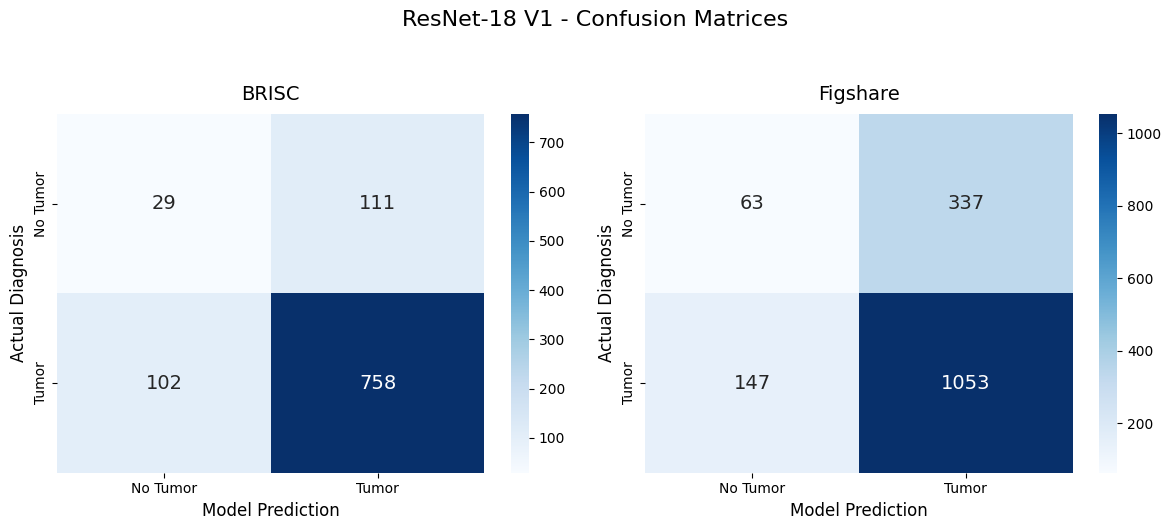

In [38]:
# --- Evaluate Model V1 ---
path_v1 = model_dir + 'Resnet v1.pth'
model_v1 = load_resnet_model(path_v1, device)

metrics_v1 = evaluate_model_multidataset(model_v1, test_loaders, device, THRESHOLD, "ResNet-18 V1")


Evaluating ResNet-18 V2 on multiple datasets...

Processing BRISC Dataset...
--- BRISC Results ---
Accuracy:    86.00% | Sensitivity: 100.00%
Specificity: 0.00% | F1-Score:    0.9247 | AUC: 0.2796

Processing Figshare Dataset...
--- Figshare Results ---
Accuracy:    75.00% | Sensitivity: 100.00%
Specificity: 0.00% | F1-Score:    0.8571 | AUC: 0.2816


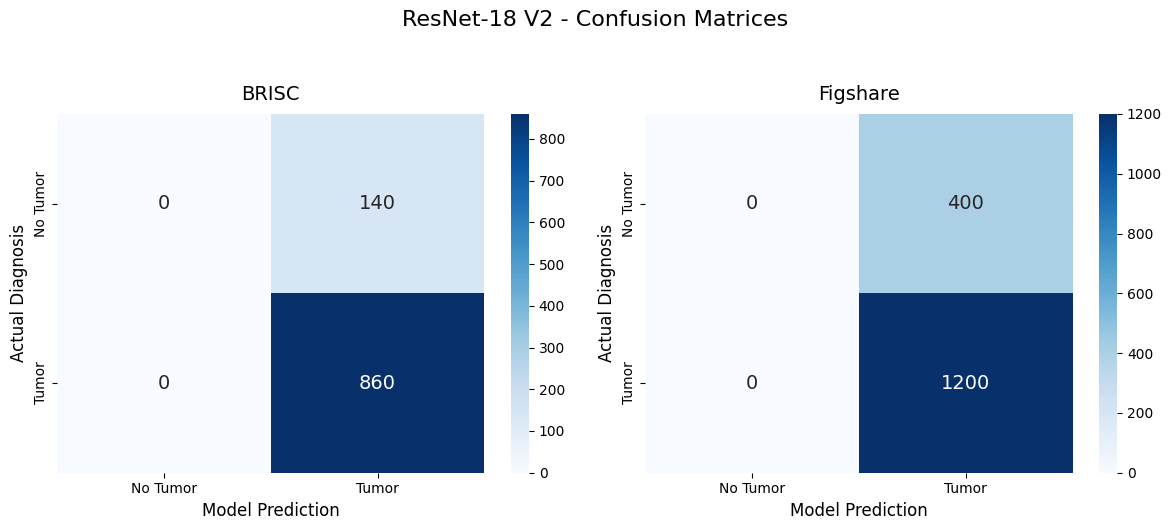

In [39]:
# --- Evaluate Model V2 ---
path_v2 = model_dir + 'Resnet v2.pth'
model_v2 = load_resnet_model(path_v2, device)

metrics_v2 = evaluate_model_multidataset(model_v2, test_loaders, device, THRESHOLD, "ResNet-18 V2")


Evaluating ResNet-18 V3 on multiple datasets...

Processing BRISC Dataset...
--- BRISC Results ---
Accuracy:    86.00% | Sensitivity: 100.00%
Specificity: 0.00% | F1-Score:    0.9247 | AUC: 0.3187

Processing Figshare Dataset...
--- Figshare Results ---
Accuracy:    75.00% | Sensitivity: 100.00%
Specificity: 0.00% | F1-Score:    0.8571 | AUC: 0.2442


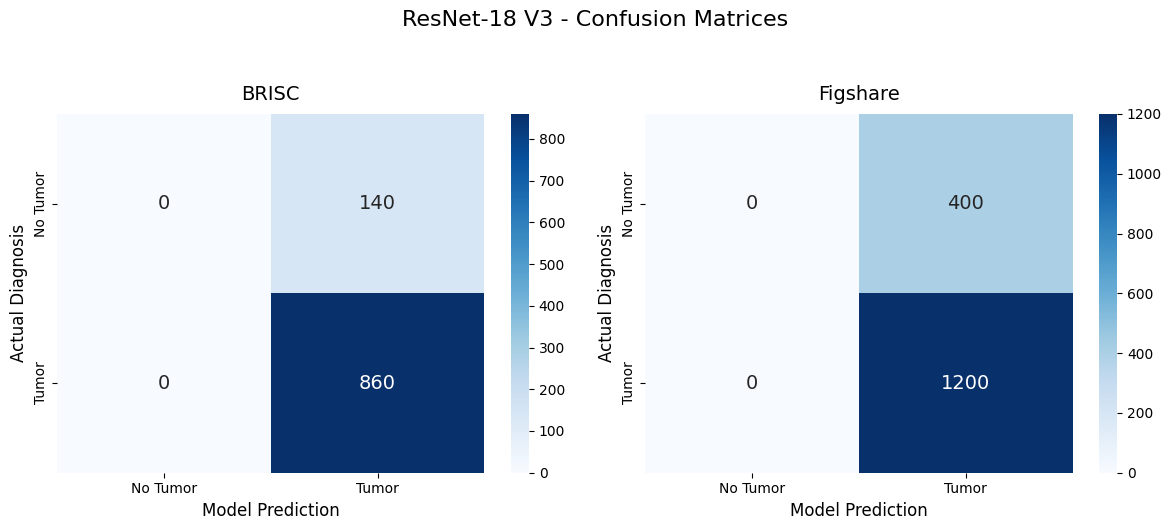

In [40]:
# --- Evaluate Model V3 ---
path_v3 = model_dir + 'Resnet v3.pth'
model_v3 = load_resnet_model(path_v3, device)

metrics_v3 = evaluate_model_multidataset(model_v3, test_loaders, device, THRESHOLD, "ResNet-18 V3")


Evaluating ResNet-18 NEW PREPROCESSING on multiple datasets...

Processing BRISC Dataset...
--- BRISC Results ---
Accuracy:    99.70% | Sensitivity: 99.65%
Specificity: 100.00% | F1-Score:    0.9983 | AUC: 1.0000

Processing Figshare Dataset...
--- Figshare Results ---
Accuracy:    93.31% | Sensitivity: 97.83%
Specificity: 79.75% | F1-Score:    0.9564 | AUC: 0.9680


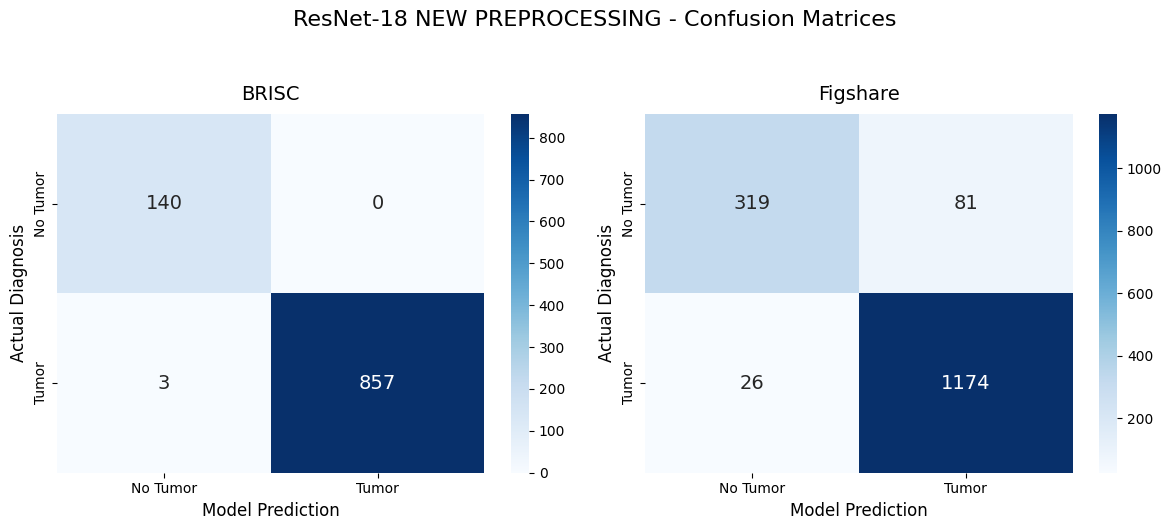

In [41]:
path_v4 = model_dir + 'preprocessed_resnet18_binary_model.pth'
model_v4 = load_resnet_model(path_v4, device)

metrics_v4 = evaluate_model_multidataset(model_v4, test_loaders, device, THRESHOLD, "ResNet-18 NEW PREPROCESSING")

In [ ]:
import pandas as pd

# Assuming multi_metrics_v1, multi_metrics_v2, and multi_metrics_v3 are the
# dictionaries returned by your new `evaluate_model_multidataset` function.

# 1. Group the results from all models
model_results = {
    "ResNet-18 V1": metrics_v1,
    "ResNet-18 V2": metrics_v2,
    "ResNet-18 V3": metrics_v3,
    "ResNet-18 NEW PREPROCESSING": metrics_v4
}

# 2. Flatten the nested dictionaries so Pandas can create a MultiIndex (Model -> Dataset)
all_metrics = {}
for model_name, dataset_dict in model_results.items():
    for dataset_name, metrics in dataset_dict.items():
        # Create a tuple key like ("ResNet-18 V1", "BRISC")
        all_metrics[(model_name, dataset_name)] = metrics

# 3. Convert to a pandas DataFrame
df_comparison = pd.DataFrame(all_metrics)

# 4. Optional: Format the numbers so they are easier to read
def format_metrics(x, metric_name):
    if metric_name in ['Accuracy', 'Sensitivity', 'Specificity']:
        return f"{x * 100:.2f}%"
    return f"{x:.4f}"

for row in df_comparison.index:
    df_comparison.loc[row] = df_comparison.loc[row].apply(lambda x: format_metrics(x, row))

# 5. Display the final multi-dataset table
print("\n=== Final Multi-Dataset Model Comparison ===")
display(df_comparison)


=== Final Multi-Dataset Model Comparison ===


/tmp/ipython-input-16420/382533080.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '95.70%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comparison.loc[row] = df_comparison.loc[row].apply(lambda x: format_metrics(x, row))
/tmp/ipython-input-16420/382533080.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '82.94%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comparison.loc[row] = df_comparison.loc[row].apply(lambda x: format_metrics(x, row))
/tmp/ipython-input-16420/382533080.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.00%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comparison.

ResNet-18 V1          ResNet-18 V2          ResNet-18 V3           \
                   BRISC Figshare        BRISC Figshare        BRISC Figshare   
Accuracy          95.70%   82.94%       99.00%   81.69%       94.70%   90.81%   
Sensitivity       99.65%   99.33%       99.30%   98.50%       94.42%   92.08%   
Specificity       71.43%   33.75%       97.14%   31.25%       96.43%   87.00%   
F1                0.9755   0.8973       0.9942   0.8897       0.9684   0.9376   
AUC               0.9896   0.8909       0.9988   0.9046       0.9920   0.9560   

            ResNet-18 NEW PREPROCESSING           
                                  BRISC Figshare  
Accuracy                         86.10%   75.50%  
Sensitivity                     100.00%  100.00%  
Specificity                       0.71%    2.00%  
F1                               0.9252   0.8596  
AUC                              0.6134   0.5372

# 6.1 Grad-CAM Visualization

In [35]:
import os

# Define the base directory to save all visualizations in Google Drive
SAVE_DIR = '/content/drive/MyDrive/interpretability_visualizations'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Save directory created at: {SAVE_DIR}")

Save directory created at: /content/drive/MyDrive/interpretability_visualizations


In [32]:
import shap
import os # Import os for directory creation

def visualize_gradcam(model, input_tensor, actual_label=None, target_layer=None, save_path=None):
    """
    Generates and plots a Grad-CAM heatmap for a given image tensor.

    Args:
        model: The trained PyTorch model.
        input_tensor: A single image tensor of shape (1, C, H, W).
        actual_label: (Optional) The true label of the image for the plot title.
        target_layer: (Optional) The convolutional layer to hook into. Defaults to ResNet layer4.
        save_path: (Optional) Path to save the plot. If None, the plot will be shown.
    """
    model.eval()

    # Default to ResNet's last conv layer if none is provided
    if target_layer is None:
        target_layer = [model.layer4[-1]]
    else:
        target_layer = [target_layer]

    # Initialize Grad-CAM
    cam = GradCAM(model=model, target_layers=target_layer)

    # Generate heatmap for the default predicted class
    targets = [ClassifierOutputTarget(0)] # Adjust if you have multi-class
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Convert tensor to RGB image for visualization (H, W, C)
    # Assuming input is in [0, 1] range. If normalized with ImageNet stats, you'd need to denormalize first.
    rgb_img = input_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()

    # Overlay heatmap
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plotting
    plt.figure(figsize=(5, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    title = f"Original MRI" if actual_label is None else f"Original MRI (True Label: {actual_label})"
    plt.title(title)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("Grad-CAM Focus Area")
    plt.axis('off')

    plt.tight_layout()
    
    # Always show in notebook first
    plt.show()
    
    # Then save if a path was provided
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved Grad-CAM visualization to {save_path}")
    
    plt.close() # Close the figure to free up memory

In [31]:
import shap
import os # Import os for directory creation

def visualize_shap(model, background_tensors, test_tensors, save_path=None):
    """
    Generates and plots SHAP pixel attribution maps.
    """
    model.eval()

    # 1. Initialize Explainer and get SHAP values
    explainer = shap.GradientExplainer(model, background_tensors)
    shap_values = explainer.shap_values(test_tensors)

    # 2. Format original test images -> Must be (Batch, Height, Width, Channels)
    test_numpy = test_tensors.cpu().detach().numpy()
    if test_numpy.ndim == 3:
        test_numpy = np.expand_dims(test_numpy, axis=0)
    if test_numpy.shape[1] in [1, 3]: # Transpose (B, C, H, W) to (B, H, W, C)
        test_numpy = np.transpose(test_numpy, (0, 2, 3, 1))

    # 3. Format SHAP values
    # Safely convert PyTorch tensors to NumPy arrays if necessary
    if torch.is_tensor(shap_values):
        shap_values = shap_values.cpu().detach().numpy()
    elif isinstance(shap_values, list) and torch.is_tensor(shap_values[0]):
        shap_values = [sv.cpu().detach().numpy() for sv in shap_values]

    # If SHAP returned a 5D array: (Classes, Batch, Channels, Height, Width)
    # We must split it into a list along the 0th axis (Classes)
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 5:
        shap_values = [shap_values[i] for i in range(shap_values.shape[0])]

    # Force it into a list if it's a single array
    if not isinstance(shap_values, list):
        shap_values = [shap_values]

    shap_numpy_list = []
    for sv in shap_values:
        if not isinstance(sv, np.ndarray):
            sv = np.array(sv)

        if sv.ndim == 3: # If single image (C, H, W), add batch dim
            sv = np.expand_dims(sv, axis=0)

        # Now we expect sv to be exactly 4D: (Batch, Channels, H, W)
        # We transpose it to match Matplotlib's (Batch, H, W, Channels)
        if sv.ndim == 4 and sv.shape[1] in [1, 3]:
            sv = np.transpose(sv, (0, 2, 3, 1))

        shap_numpy_list.append(sv)

    # 4. Plot - shap.image_plot creates its own figure
    print("Generating SHAP plots (Red = pushes to Tumor, Blue = pushes to No Tumor)...")
    shap.image_plot(shap_numpy_list, test_numpy)
    
    # Get the current figure
    fig = plt.gcf()
    fig.set_size_inches(10, 5)
    
    # Show the current figure in the notebook
    plt.show()
    
    # Save if path was provided
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved SHAP visualization to {save_path}")
    
    plt.close(fig)

### 6.2 Grad-CAM and SHAP Visualization for Figshare Dataset

In [33]:
def generate_interpretability_visualizations(model, data_loader, dataset_name, device, model_name):
    """
    Generates Grad-CAM and SHAP visualizations for a given model and dataset.

    Args:
        model: The trained PyTorch model.
        data_loader: DataLoader for the dataset.
        dataset_name: Name of the dataset (string) for printing headers.
        device: The device to run on (e.g., 'cuda' or 'cpu').
        model_name: Name of the model for saving files.
    """
    print(f"\n--- Visualizations for {model_name} on {dataset_name} Dataset ---")

    # 2. Get an iterator and extract one batch
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    # 3. Move images to the specified device
    images = images.to(device)

    # 4. For Grad-CAM, select a single image (e.g., the 20th image) from the batch
    # and its corresponding label.
    # Check if batch has at least 20 images, otherwise take the last one or first one
    idx_gradcam = min(20, images.shape[0] - 1) if images.shape[0] > 0 else 0
    single_image_tensor = images[idx_gradcam].unsqueeze(0)
    single_label = labels[idx_gradcam].item()

    # Construct save path for Grad-CAM
    gradcam_filename = f"gradcam_{model_name}_{dataset_name}_image_{idx_gradcam}.png"
    gradcam_save_path = os.path.join(SAVE_DIR, gradcam_filename)

    print(f"Generating Grad-CAM for an image from {dataset_name} (saving to {gradcam_save_path})...")
    visualize_gradcam(
        model=model,
        input_tensor=single_image_tensor,
        actual_label=single_label,
        save_path=gradcam_save_path
    )

    # 5. For SHAP, use the entire batch of `images` as `background_tensors`.
    # Select a subset of images (e.g., the first 3 images) from the batch as `test_tensors`.
    background = images
    idx_shap = min(3, images.shape[0]) # Take up to 3 images, or fewer if batch is smaller
    images_to_explain = images[0:idx_shap]

    # Construct save path for SHAP
    shap_filename = f"shap_{model_name}_{dataset_name}_images_{idx_shap}.png"
    shap_save_path = os.path.join(SAVE_DIR, shap_filename)

    if images_to_explain.shape[0] > 0:
        print(f"Generating SHAP explanations for {idx_shap} images from {dataset_name} (saving to {shap_save_path})...")
        visualize_shap(
            model=model,
            background_tensors=background,
            test_tensors=images_to_explain,
            save_path=shap_save_path
        )
    else:
        print(f"Skipping SHAP: Not enough images in the batch from {dataset_name} to explain.")

print("Function `generate_interpretability_visualizations` defined (updated for saving).")

Function `generate_interpretability_visualizations` defined (updated for saving).


**Reasoning**:
The previous step defined the `generate_interpretability_visualizations` function. Now, to fulfill the task of using this function, it needs to be called with the appropriate arguments for each dataset (BRISC and Figshare) using the `model_v1` that was loaded earlier.



In [29]:
print("\n--- Generating Interpretability Visualizations for BRISC and Figshare Datasets ---")

# Call the function for the BRISC dataset with model_v1
generate_interpretability_visualizations(
    model=model_v1,
    data_loader=test_loaders["BRISC"],
    dataset_name="BRISC",
    device=device,
    model_name="ResNet-18 V1"
)

# Call the function for the Figshare dataset with model_v1
generate_interpretability_visualizations(
    model=model_v1,
    data_loader=test_loaders["Figshare"],
    dataset_name="Figshare",
    device=device,
    model_name="ResNet-18 V1"
)


--- Generating Interpretability Visualizations for BRISC and Figshare Datasets ---


NameError: name 'generate_interpretability_visualizations' is not defined

## Visualize Model V2

### Subtask:
Call the `generate_interpretability_visualizations` function for `model_v2` with both the `brics_test_loader` and `figshare_test_loader` to show Grad-CAM and SHAP for the second model on both datasets.


**Reasoning**:
The subtask requires calling the `generate_interpretability_visualizations` function for `model_v2` on both the BRISC and Figshare datasets, which was previously defined. This involves printing a header and then making two separate calls to the function.




--- Generating Interpretability Visualizations for Model V2 (BRISC and Figshare Datasets) ---

--- Visualizations for ResNet-18 V2 on BRISC Dataset ---
Generating Grad-CAM for an image from BRISC (saving to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V2_BRISC_image_20.png)...


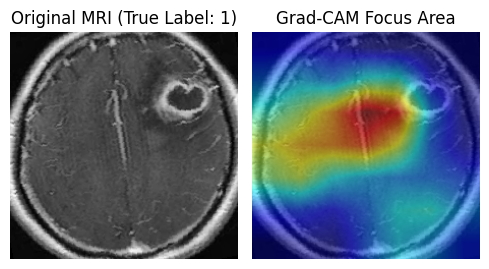

Saved Grad-CAM visualization to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V2_BRISC_image_20.png
Generating SHAP explanations for 3 images from BRISC (saving to /content/drive/MyDrive/interpretability_visualizations/shap_ResNet-18 V2_BRISC_images_3.png)...
Generating SHAP plots (Red = pushes to Tumor, Blue = pushes to No Tumor)...


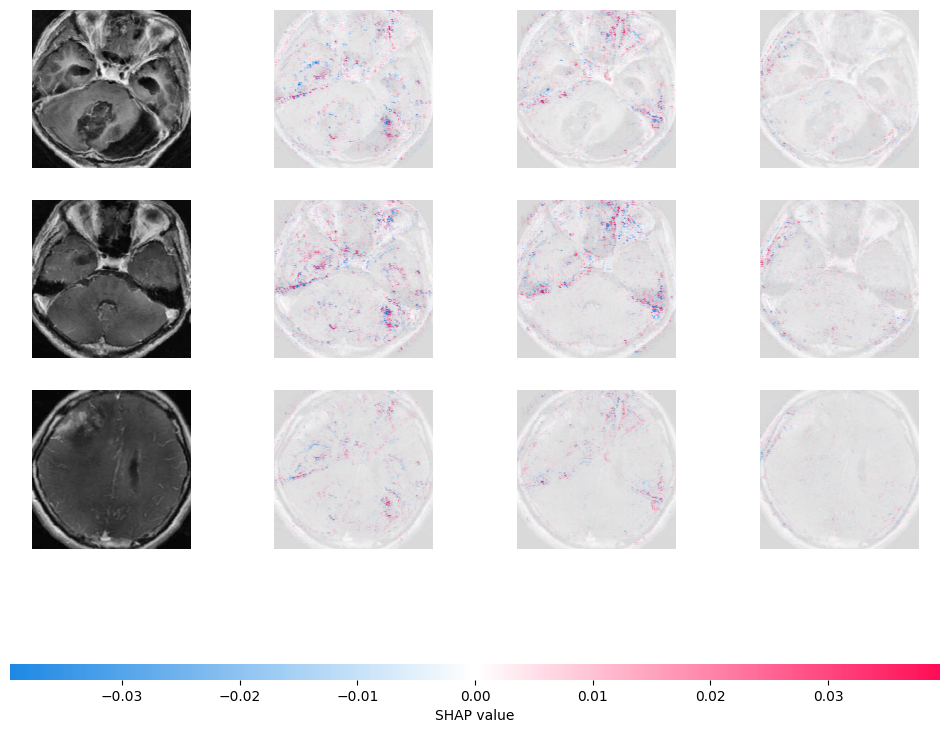

<Figure size 1000x500 with 0 Axes>

Saved SHAP visualization to /content/drive/MyDrive/interpretability_visualizations/shap_ResNet-18 V2_BRISC_images_3.png

--- Visualizations for ResNet-18 V2 on Figshare Dataset ---
Generating Grad-CAM for an image from Figshare (saving to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V2_Figshare_image_20.png)...


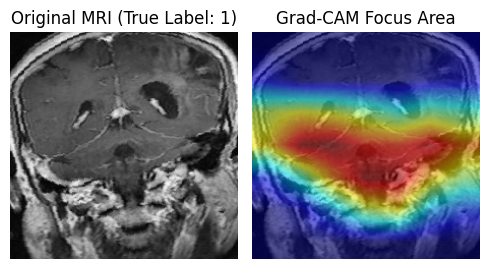

Saved Grad-CAM visualization to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V2_Figshare_image_20.png
Generating SHAP explanations for 3 images from Figshare (saving to /content/drive/MyDrive/interpretability_visualizations/shap_ResNet-18 V2_Figshare_images_3.png)...
Generating SHAP plots (Red = pushes to Tumor, Blue = pushes to No Tumor)...


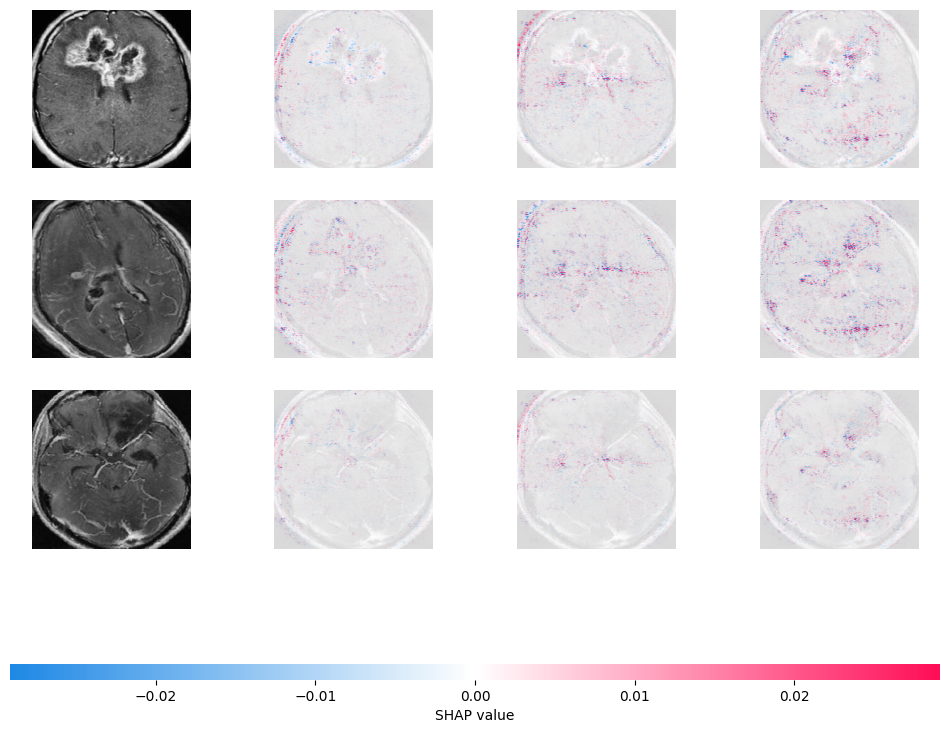

<Figure size 1000x500 with 0 Axes>

Saved SHAP visualization to /content/drive/MyDrive/interpretability_visualizations/shap_ResNet-18 V2_Figshare_images_3.png


In [ ]:
print("\n--- Generating Interpretability Visualizations for Model V2 (BRISC and Figshare Datasets) ---")

# Call the function for the BRISC dataset with model_v2
generate_interpretability_visualizations(
    model=model_v2,
    data_loader=test_loaders["BRISC"],
    dataset_name="BRISC",
    device=device,
    model_name="ResNet-18 V2"
)

# Call the function for the Figshare dataset with model_v2
generate_interpretability_visualizations(
    model=model_v2,
    data_loader=test_loaders["Figshare"],
    dataset_name="Figshare",
    device=device,
    model_name="ResNet-18 V2"
)

## Visualize Model V3

### Subtask:
Call the `generate_interpretability_visualizations` function for `model_v3` with both the `brics_test_loader` and `figshare_test_loader` to show Grad-CAM and SHAP for the third model on both datasets.


**Reasoning**:
The subtask requires calling the `generate_interpretability_visualizations` function for `model_v3` on both the BRISC and Figshare datasets, following the instructions to print a header and then make two separate calls to the function.




--- Generating Interpretability Visualizations for Model V3 (BRISC and Figshare Datasets) ---

--- Visualizations for ResNet-18 V3 on BRISC Dataset ---
Generating Grad-CAM for an image from BRISC (saving to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V3_BRISC_image_20.png)...


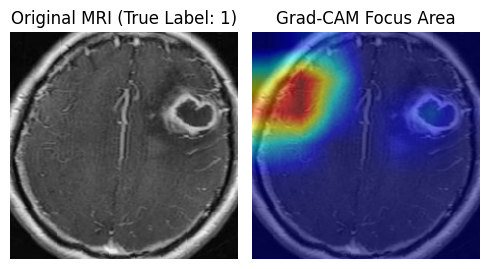

Saved Grad-CAM visualization to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V3_BRISC_image_20.png
Generating SHAP explanations for 3 images from BRISC (saving to /content/drive/MyDrive/interpretability_visualizations/shap_ResNet-18 V3_BRISC_images_3.png)...
Generating SHAP plots (Red = pushes to Tumor, Blue = pushes to No Tumor)...


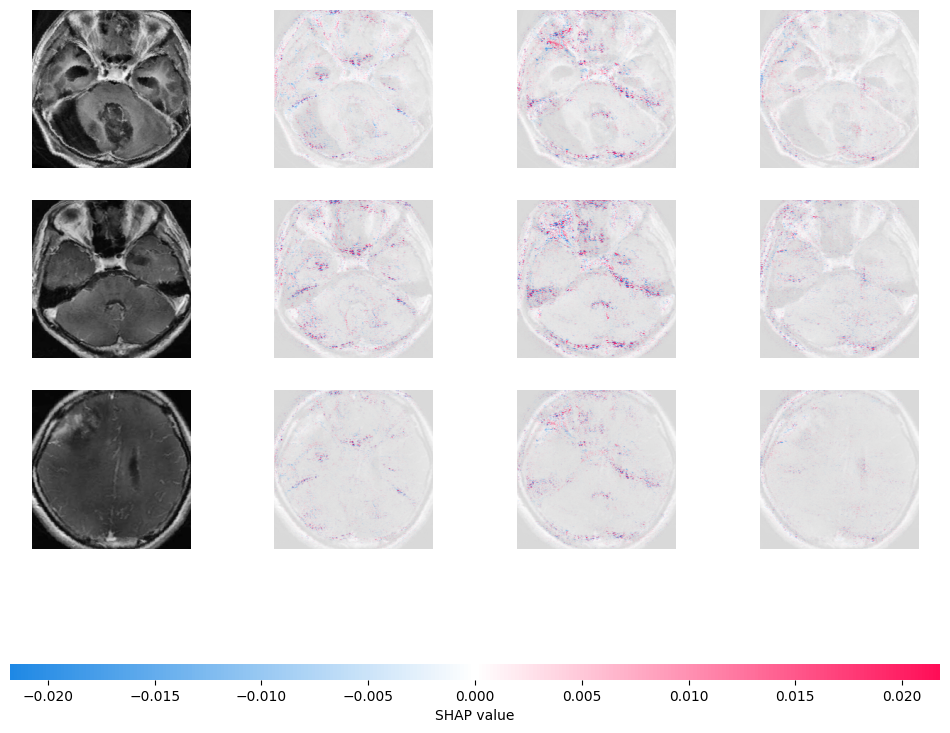

<Figure size 1000x500 with 0 Axes>

Saved SHAP visualization to /content/drive/MyDrive/interpretability_visualizations/shap_ResNet-18 V3_BRISC_images_3.png

--- Visualizations for ResNet-18 V3 on Figshare Dataset ---
Generating Grad-CAM for an image from Figshare (saving to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V3_Figshare_image_20.png)...


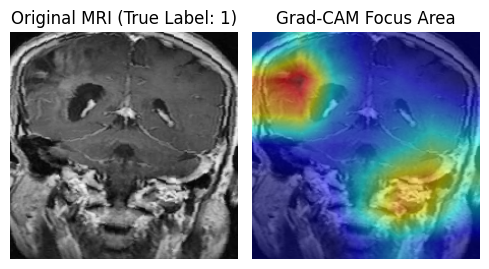

Saved Grad-CAM visualization to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V3_Figshare_image_20.png
Generating SHAP explanations for 3 images from Figshare (saving to /content/drive/MyDrive/interpretability_visualizations/shap_ResNet-18 V3_Figshare_images_3.png)...
Generating SHAP plots (Red = pushes to Tumor, Blue = pushes to No Tumor)...


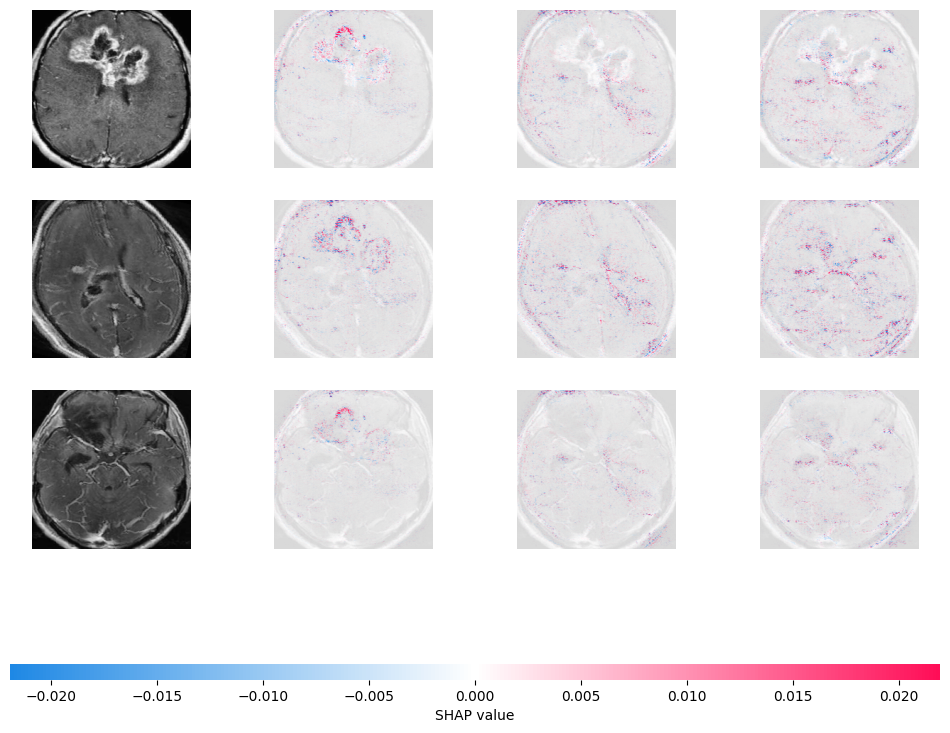

<Figure size 1000x500 with 0 Axes>

Saved SHAP visualization to /content/drive/MyDrive/interpretability_visualizations/shap_ResNet-18 V3_Figshare_images_3.png


In [ ]:
print("\n--- Generating Interpretability Visualizations for Model V3 (BRISC and Figshare Datasets) ---")

# Call the function for the BRISC dataset with model_v3
generate_interpretability_visualizations(
    model=model_v3,
    data_loader=test_loaders["BRISC"],
    dataset_name="BRISC",
    device=device,
    model_name="ResNet-18 V3"
)

# Call the function for the Figshare dataset with model_v3
generate_interpretability_visualizations(
    model=model_v3,
    data_loader=test_loaders["Figshare"],
    dataset_name="Figshare",
    device=device,
    model_name="ResNet-18 V3"
)

In [42]:
print("\n--- Generating Interpretability Visualizations for BRISC and Figshare Datasets ---")

# Call the function for the BRISC dataset with model_v4
generate_interpretability_visualizations(
    model=model_v4,
    data_loader=test_loaders["BRISC"],
    dataset_name="BRISC",
    device=device,
    model_name="ResNet-18 V1"
)

# Call the function for the Figshare dataset with model_v4
generate_interpretability_visualizations(
    model=model_v4,
    data_loader=test_loaders["Figshare"],
    dataset_name="Figshare",
    device=device,
    model_name="ResNet-18 V1"
)


--- Generating Interpretability Visualizations for BRISC and Figshare Datasets ---

--- Visualizations for ResNet-18 V1 on BRISC Dataset ---
Generating Grad-CAM for an image from BRISC (saving to /content/drive/MyDrive/interpretability_visualizations/gradcam_ResNet-18 V1_BRISC_image_20.png)...


Exception: The input image should np.float32 in the range [0, 1]